In [8]:
import numpy as np
import pandas as pd

np.random.seed(42)

years = np.arange(2000,2030)

# simulate realistic trends
workforce = 2500000 + (years-2000)*30000 + np.random.normal(0,50000,len(years))

avg_salary = 3000 + (years-2000)*120 + np.random.normal(0,200,len(years))

contribution_rate = 0.20

ts = pd.DataFrame({
    "year": years,
    "workforce": workforce,
    "avg_salary": avg_salary,
    "contribution_rate": contribution_rate
})

ts["total_contribution"] = (
ts["workforce"] *
ts["avg_salary"] *
ts["contribution_rate"] *
12
)

ts.head()

,year,workforce,avg_salary,contribution_rate,total_contribution
0,2000,2.524836e+06,2879.658678,0.2,1.744960e+10
1,2001,2.523087e+06,3490.455637,0.2,2.113613e+10
2,2002,2.592384e+06,3237.300555,0.2,2.014159e+10
3,2003,2.666151e+06,3148.457814,0.2,2.014624e+10
4,2004,2.608292e+06,3644.508982,0.2,2.281427e+10


In [9]:
# Regression Forecast
from sklearn.linear_model import LinearRegression

X = ts[["year"]]

y = ts["total_contribution"]

model = LinearRegression()

model.fit(X,y)

future_years = pd.DataFrame({"year":np.arange(2030,2040)})

forecast = model.predict(future_years)

future_years["forecast_contribution"] = forecast

future_years

,year,forecast_contribution
0,2030,5.220302e+10
1,2031,5.339419e+10
2,2032,5.458535e+10
3,2033,5.577652e+10
4,2034,5.696768e+10
5,2035,5.815885e+10
6,2036,5.935001e+10
7,2037,6.054118e+10
8,2038,6.173234e+10
9,2039,6.292351e+10


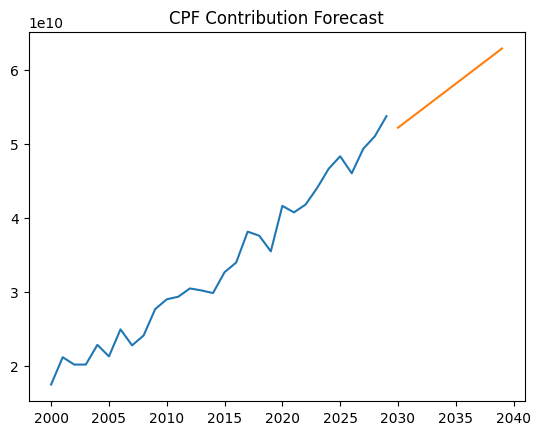

In [10]:
# Plot Forecast
import matplotlib.pyplot as plt
plt.plot(ts["year"],ts["total_contribution"])

plt.plot(future_years["year"],forecast)

plt.title("CPF Contribution Forecast")

plt.show()